# Hyena Layer — Minimal Toy Implementation

Three genomic tracks, each `(batch, 128, 100)` — **ATAC**, **Methylation**, **DNA features**.

Architecture per track:
```
input (B, D, L)
  → input projection  (D → 3D)  [produces q, k, v]
  → depthwise conv    (short conv on k, v)
  → long convolution  (FFT-based, learned filter h)
  → output projection (D → D)
```

In [1]:
import io
import logging
import warnings
from contextlib import redirect_stderr, redirect_stdout

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig
import pyfaidx
import pyranges as pr
import pysam
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
from evo2 import Evo2

Supported flash-attn versions are >= 2.1.1, <= 2.7.4.post1. Found flash-attn 2.8.0.post2.


In [2]:
class HyenaFilter(nn.Module):
    """
    Implicit (MLP-based) long convolution filter.
    Maps positional encodings to a filter h of shape (d_model, L).
    """
    def __init__(self, d_model: int, seq_len: int, emb_dim: int = 64, num_layers: int = 3):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model

        # Positional embedding: sine/cosine at multiple frequencies
        t = torch.linspace(0, 1, seq_len).unsqueeze(-1)  # (L, 1)
        freqs = 2 * torch.pi * torch.arange(1, emb_dim // 2 + 1).float()  # (emb_dim//2,)
        pos_enc = torch.cat([torch.sin(t * freqs), torch.cos(t * freqs)], dim=-1)  # (L, emb_dim)
        self.register_buffer("pos_enc", pos_enc)

        # Small MLP: pos_enc -> filter values
        layers = []
        in_dim = emb_dim
        for _ in range(num_layers - 1):
            layers += [nn.Linear(in_dim, emb_dim), nn.SiLU()]
            in_dim = emb_dim
        layers.append(nn.Linear(in_dim, d_model))
        self.mlp = nn.Sequential(*layers)

        # Learned exponential decay to ensure causality and stability
        self.log_decay = nn.Parameter(torch.zeros(d_model))

    def forward(self) -> torch.Tensor:
        """Returns filter h of shape (d_model, L)."""
        h = self.mlp(self.pos_enc)              # (L, d_model)
        decay = torch.exp(-self.log_decay.abs()) ** torch.arange(self.seq_len, device=h.device).unsqueeze(-1)
        h = h * decay
        return h.transpose(0, 1)               # (d_model, L)


class HyenaLayer(nn.Module):
    """
    Minimal order-2 Hyena layer.

    Input:  (B, L, D)
    Output: (B, L, D)
    """
    def __init__(self, d_model: int, seq_len: int, short_kernel: int = 3):
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len

        self.in_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.short_conv_k = nn.Conv1d(
            d_model, d_model, kernel_size=short_kernel,
            padding=short_kernel - 1, groups=d_model, bias=True
        )
        self.short_conv_v = nn.Conv1d(
            d_model, d_model, kernel_size=short_kernel,
            padding=short_kernel - 1, groups=d_model, bias=True
        )
        self.filter = HyenaFilter(d_model, seq_len)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.act = nn.SiLU()

    def _fft_long_conv(self, u: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        L = u.shape[-1]
        fft_size = 2 * L
        u_f = torch.fft.rfft(u.float(), n=fft_size)
        h_f = torch.fft.rfft(h.float(), n=fft_size)
        y = torch.fft.irfft(u_f * h_f, n=fft_size)[..., :L]
        return y.to(u.dtype)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, D = x.shape
        qkv = self.in_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        k = self.short_conv_k(k)[..., :L]
        v = self.short_conv_v(v)[..., :L]

        h = self.filter()
        y = self._fft_long_conv(k * v, h)

        q = q.transpose(1, 2)
        y = self.act(q) * y
        return self.out_proj(y.transpose(1, 2))


class CrossHyenaLayer(nn.Module):
    """
    Cross-Hyena layer.

    Like cross-attention:
    - q comes from the query track x
    - k and v come from the context track

    But instead of softmax(qk^T)v, we build a long convolutional context signal
    from k * v and gate it with q.

    Input:
        x:       (B, L, D)
        context: (B, L, D)
    Output:
        (B, L, D)
    """
    def __init__(self, d_model: int, seq_len: int, short_kernel: int = 3):
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.kv_proj = nn.Linear(d_model, 2 * d_model, bias=False)
        self.short_conv_k = nn.Conv1d(
            d_model, d_model, kernel_size=short_kernel,
            padding=short_kernel - 1, groups=d_model, bias=True
        )
        self.short_conv_v = nn.Conv1d(
            d_model, d_model, kernel_size=short_kernel,
            padding=short_kernel - 1, groups=d_model, bias=True
        )
        self.filter = HyenaFilter(d_model, seq_len)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.act = nn.SiLU()

    def _fft_long_conv(self, u: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        L = u.shape[-1]
        fft_size = 2 * L
        u_f = torch.fft.rfft(u.float(), n=fft_size)
        h_f = torch.fft.rfft(h.float(), n=fft_size)
        y = torch.fft.irfft(u_f * h_f, n=fft_size)[..., :L]
        return y.to(u.dtype)

    def forward(self, x: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        _, L, _ = x.shape

        q = self.q_proj(x)
        kv = self.kv_proj(context)
        k, v = kv.chunk(2, dim=-1)

        k = self.short_conv_k(k.transpose(1, 2))[..., :L]
        v = self.short_conv_v(v.transpose(1, 2))[..., :L]

        h = self.filter()
        y = self._fft_long_conv(k * v, h)

        q = q.transpose(1, 2)
        y = self.act(q) * y
        return self.out_proj(y.transpose(1, 2))

In [3]:
class MultiTrackHyena(nn.Module):
    """
    Applies a separate HyenaLayer to each genomic track,
    then fuses them with a learned linear projection.

    Tracks: ATAC, Methylation, DNA features
    Each track: (B, L, D) where L=100, D=128
    """
    def __init__(self, d_model: int = 128, seq_len: int = 100):
        super().__init__()
        self.tracks = nn.ModuleDict({
            "atac":        HyenaLayer(d_model, seq_len),
            "methylation": HyenaLayer(d_model, seq_len),
            "dna":         HyenaLayer(d_model, seq_len),
        })
        # Fuse all three tracks into one representation
        self.fusion = nn.Linear(3 * d_model, d_model, bias=False)

    def forward(
        self,
        atac: torch.Tensor,         # (B, L, D)
        methylation: torch.Tensor,  # (B, L, D)
        dna: torch.Tensor,          # (B, L, D)
    ) -> torch.Tensor:              # (B, L, D)
        y_atac  = self.tracks["atac"](atac)
        y_meth  = self.tracks["methylation"](methylation)
        y_dna   = self.tracks["dna"](dna)
        # Concatenate along feature dim and project back
        fused = torch.cat([y_atac, y_meth, y_dna], dim=-1)  # (B, L, 3D)
        return self.fusion(fused)                             # (B, L, D)

In [4]:
class MultiTrackCrossHyena(nn.Module):
    """
    Multi-track Cross-Hyena block focused on a target track.

    For this toy case, DNA is the query track and attends to two context tracks:
    - DNA <- methylation
    - DNA <- ATAC

    The block computes:
        self_dna = HyenaLayer(dna)
        dna_from_methylation = CrossHyenaLayer(dna, methylation)
        dna_from_atac = CrossHyenaLayer(dna, atac)

    Then fuses the three DNA representations back to one output.
    """
    def __init__(self, d_model: int = 128, seq_len: int = 100):
        super().__init__()
        self.dna_self = HyenaLayer(d_model, seq_len)
        self.dna_from_methylation = CrossHyenaLayer(d_model, seq_len)
        self.dna_from_atac = CrossHyenaLayer(d_model, seq_len)
        self.fusion = nn.Linear(3 * d_model, d_model, bias=False)

    def forward(
        self,
        atac: torch.Tensor,
        methylation: torch.Tensor,
        dna: torch.Tensor,
    ) -> torch.Tensor:
        dna_self = self.dna_self(dna)
        dna_cross_methylation = self.dna_from_methylation(dna, methylation)
        dna_cross_atac = self.dna_from_atac(dna, atac)

        fused = torch.cat(
            [dna_self, dna_cross_methylation, dna_cross_atac],
            dim=-1,
        )
        return self.fusion(fused)

In [5]:
# ─── Toy forward pass ────────────────────────────────────────────────────────
B, L, D = 2, 100, 128

model = MultiTrackHyena(d_model=D, seq_len=L)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

atac        = torch.randn(B, L, D)
methylation = torch.randn(B, L, D)
dna         = torch.randn(B, L, D)

out = model(atac, methylation, dna)
print(f"Input  shape : {atac.shape}")   # (2, 100, 128)
print(f"Output shape : {out.shape}")    # (2, 100, 128)

Parameters: 299,136
Input  shape : torch.Size([2, 100, 128])
Output shape : torch.Size([2, 100, 128])


In [6]:
# 第一版

# ATAC <- DNA
# 5mC <- DNA
# 5hmC <- DNA
# 也就是三个任务都先只看 DNA。

# 第二版

# 再加 assay 之间的横向帮助：
# ATAC <- 5mC
# ATAC <- 5hmC
# 5mC <- ATAC
# 5mC <- 5hmC
# 5hmC <- ATAC
# 5hmC <- 5mC

In [7]:
# ─── MultiTrackCrossHyena toy forward pass ───────────────────────────────────
multitrack_cross_model = MultiTrackCrossHyena(d_model=D, seq_len=L)
print(f"MultiTrackCrossHyena parameters: {sum(p.numel() for p in multitrack_cross_model.parameters()):,}")

multitrack_cross_out = multitrack_cross_model(atac, methylation, dna)
print(f"DNA query input shape          : {dna.shape}")
print(f"Methylation context shape      : {methylation.shape}")
print(f"ATAC context shape             : {atac.shape}")
print(f"MultiTrackCrossHyena out shape : {multitrack_cross_out.shape}")

multitrack_cross_loss = multitrack_cross_out.sum()
multitrack_cross_loss.backward()
print("MultiTrackCrossHyena backward pass OK")

MultiTrackCrossHyena parameters: 299,136
DNA query input shape          : torch.Size([2, 100, 128])
Methylation context shape      : torch.Size([2, 100, 128])
ATAC context shape             : torch.Size([2, 100, 128])
MultiTrackCrossHyena out shape : torch.Size([2, 100, 128])
MultiTrackCrossHyena backward pass OK


In [8]:
# Cross-Hyena example: ATAC queries DNA
cross_layer = CrossHyenaLayer(d_model=D, seq_len=L)

cross_out = cross_layer(atac, dna)
print(f"Cross input query shape   : {atac.shape}")
print(f"Cross input context shape : {dna.shape}")
print(f"Cross output shape        : {cross_out.shape}")

cross_loss = cross_out.sum()
cross_loss.backward()
print("Cross-Hyena backward pass OK")

Cross input query shape   : torch.Size([2, 100, 128])
Cross input context shape : torch.Size([2, 100, 128])
Cross output shape        : torch.Size([2, 100, 128])
Cross-Hyena backward pass OK


In [9]:
# ─── Quick gradient check ─────────────────────────────────────────────────────
loss = out.sum()
loss.backward()
print("Backward pass OK")

# Inspect filter shape for the ATAC track
h = model.tracks["atac"].filter()
print(f"ATAC filter h shape : {h.shape}")   # (128, 100)

Backward pass OK
ATAC filter h shape : torch.Size([128, 100])


## Two-Stage Cross-Hyena Demo for Masked Methylation Reconstruction

Toy setup aligned with your design:

- Inputs: sequence features, ATAC, 5mC, 5hmC
- Stage 1: use `ATAC` as query and `sequence` as context to build a sequence-aware ATAC representation
- Stage 2: use masked `5mC` / `5hmC` as queries, and the fused `sequence + ATAC-conditioned + raw feature` representation as context
- Objective: only reconstruct masked methylation positions for `5mC` and `5hmC`

This version masks only 15% of CpG positions, treating both `CG` and the reverse-complement view `GC` as valid candidates.

In [10]:
def find_cpg_candidate_positions(base_ids: torch.Tensor) -> torch.Tensor:
    """Return positions that belong to a CpG dinucleotide on either strand.

    A position is eligible if it is:
    - a C followed by G (`CG`) on the forward strand, or
    - a G preceded by C (`GC`) so the complementary-strand view is also covered.
    """
    if base_ids.ndim != 2:
        raise ValueError("base_ids must have shape (batch_size, seq_len)")

    is_c = base_ids == 1
    is_g = base_ids == 2

    right_is_g = torch.zeros_like(is_g)
    right_is_g[:, :-1] = is_g[:, 1:]

    left_is_c = torch.zeros_like(is_c)
    left_is_c[:, 1:] = is_c[:, :-1]

    return (is_c & right_is_g) | (is_g & left_is_c)


def mask_track_cpg_sites(
    track: torch.Tensor,
    base_ids: torch.Tensor,
    mask_ratio: float = 0.15,
):
    """Mask 15% of eligible CpG positions in a continuous methylation track.

    Returns:
        masked_track: input with selected CpG positions zeroed out
        observed_mask: 1 where the original signal is visible, 0 where masked
        loss_mask:     1 where reconstruction loss should be applied
        candidate_mask: 1 at CpG candidate positions (`CG` or reverse-complement `GC`)
    """
    batch_size, seq_len, _ = track.shape
    if base_ids.shape != (batch_size, seq_len):
        raise ValueError("base_ids must have shape (batch_size, seq_len) and match track")

    candidate_mask = find_cpg_candidate_positions(base_ids).to(track.device)
    masked_track = track.clone()
    loss_mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=track.device)

    for batch_idx in range(batch_size):
        candidate_positions = torch.nonzero(candidate_mask[batch_idx], as_tuple=False).flatten()
        if candidate_positions.numel() == 0:
            continue

        num_to_mask = max(1, int(round(candidate_positions.numel() * mask_ratio)))
        num_to_mask = min(num_to_mask, candidate_positions.numel())
        selection = torch.randperm(candidate_positions.numel(), device=track.device)[:num_to_mask]
        masked_positions = candidate_positions[selection]
        loss_mask[batch_idx, masked_positions] = True

    masked_track[loss_mask] = 0.0
    observed_mask = (~loss_mask).float().unsqueeze(-1)
    return masked_track, observed_mask, loss_mask, candidate_mask


class MethylationMaskEmbedding(nn.Module):
    """Adds a learned vector at masked positions so zeroed values are distinguishable from true low values."""

    def __init__(self, d_model: int):
        super().__init__()
        self.mask_embedding = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.mask_embedding, std=0.02)

    def forward(self, x: torch.Tensor, observed_mask: torch.Tensor) -> torch.Tensor:
        return x * observed_mask + self.mask_embedding * (1.0 - observed_mask)


class SequenceAwareATACEncoder(nn.Module):
    """Stage 1: ATAC does the querying, sequence provides context."""

    def __init__(self, d_model: int = 128, seq_len: int = 100):
        super().__init__()
        self.atac_from_sequence = CrossHyenaLayer(d_model, seq_len)
        self.atac_self = HyenaLayer(d_model, seq_len)
        self.fusion = nn.Linear(2 * d_model, d_model, bias=False)

    def forward(self, atac: torch.Tensor, sequence: torch.Tensor) -> torch.Tensor:
        atac_self = self.atac_self(atac)
        atac_from_sequence = self.atac_from_sequence(atac, sequence)
        return self.fusion(torch.cat([atac_self, atac_from_sequence], dim=-1))


class MaskedMethylationCrossHyena(nn.Module):
    """Two-stage toy model.

    Stage 1:
      ATAC <- sequence

    Stage 2:
      5mC  <- fused(sequence, raw_atac, sequence-aware_atac)
      5hmC <- fused(sequence, raw_atac, sequence-aware_atac)

    The methylation queries are masked, and reconstruction loss is only computed
    on masked positions.
    """

    def __init__(self, d_model: int = 128, seq_len: int = 100):
        super().__init__()
        self.stage1 = SequenceAwareATACEncoder(d_model=d_model, seq_len=seq_len)

        self.context_fusion = nn.Linear(3 * d_model, d_model, bias=False)

        self.m5c_mask_embedding = MethylationMaskEmbedding(d_model)
        self.hm5c_mask_embedding = MethylationMaskEmbedding(d_model)

        self.m5c_from_context = CrossHyenaLayer(d_model, seq_len)
        self.hm5c_from_context = CrossHyenaLayer(d_model, seq_len)

        self.m5c_head = nn.Linear(d_model, d_model)
        self.hm5c_head = nn.Linear(d_model, d_model)

    def build_context(self, atac: torch.Tensor, sequence: torch.Tensor) -> torch.Tensor:
        atac_seq = self.stage1(atac, sequence)
        fused_context = torch.cat([sequence, atac, atac_seq], dim=-1)
        return self.context_fusion(fused_context)

    def forward(
        self,
        atac: torch.Tensor,
        sequence: torch.Tensor,
        m5c: torch.Tensor,
        hm5c: torch.Tensor,
        m5c_observed_mask: torch.Tensor,
        hm5c_observed_mask: torch.Tensor,
    ):
        context = self.build_context(atac, sequence)
        #context = sequence
        masked_m5c = self.m5c_mask_embedding(m5c, m5c_observed_mask)
        masked_hm5c = self.hm5c_mask_embedding(hm5c, hm5c_observed_mask)

        m5c_hidden = self.m5c_from_context(masked_m5c, context)
        hm5c_hidden = self.hm5c_from_context(masked_hm5c, context)

        m5c_recon = self.m5c_head(m5c_hidden)
        hm5c_recon = self.hm5c_head(hm5c_hidden)

        return {
            "context": context,
            "m5c_recon": m5c_recon,
            "hm5c_recon": hm5c_recon,
        }


def masked_reconstruction_loss(pred: torch.Tensor, target: torch.Tensor, loss_mask: torch.Tensor) -> torch.Tensor:
    squared_error = (pred - target).pow(2).mean(dim=-1)
    weights = loss_mask.float()
    return (squared_error * weights).sum() / weights.sum().clamp_min(1.0)

In [11]:
# ─── Masked methylation reconstruction demo ───────────────────────────────────
B, L, D = 2, 100, 128

torch.manual_seed(7)

base_ids = torch.randint(0, 4, (B, L))
sequence_embedding = nn.Embedding(4, D)
sequence = sequence_embedding(base_ids)

atac = torch.randn(B, L, D)
m5c = torch.randn(B, L, D)
hm5c = torch.randn(B, L, D)

masked_m5c, m5c_observed_mask, m5c_loss_mask, cpg_candidate_mask = mask_track_cpg_sites(
    m5c,
    base_ids,
    mask_ratio=0.15,
)
masked_hm5c, hm5c_observed_mask, hm5c_loss_mask, _ = mask_track_cpg_sites(
    hm5c,
    base_ids,
    mask_ratio=0.15,
)

methylation_model = MaskedMethylationCrossHyena(d_model=D, seq_len=L)
outputs = methylation_model(
    atac=atac,
    sequence=sequence,
    m5c=masked_m5c,
    hm5c=masked_hm5c,
    m5c_observed_mask=m5c_observed_mask,
    hm5c_observed_mask=hm5c_observed_mask,
)

m5c_loss = masked_reconstruction_loss(outputs["m5c_recon"], m5c, m5c_loss_mask)
hm5c_loss = masked_reconstruction_loss(outputs["hm5c_recon"], hm5c, hm5c_loss_mask)
total_loss = m5c_loss + hm5c_loss

total_loss.backward()

print(f"sequence shape            : {sequence.shape}")
print(f"atac shape                : {atac.shape}")
print(f"masked 5mC shape          : {masked_m5c.shape}")
print(f"masked 5hmC shape         : {masked_hm5c.shape}")
print(f"fused context shape       : {outputs['context'].shape}")
print(f"5mC reconstruction shape  : {outputs['m5c_recon'].shape}")
print(f"5hmC reconstruction shape : {outputs['hm5c_recon'].shape}")
print(f"CpG candidate positions   : {cpg_candidate_mask.sum().item()}")
print(f"5mC masked positions      : {m5c_loss_mask.sum().item()}")
print(f"5hmC masked positions     : {hm5c_loss_mask.sum().item()}")
print(f"5mC masked recon loss     : {m5c_loss.item():.6f}")
print(f"5hmC masked recon loss    : {hm5c_loss.item():.6f}")
print(f"total masked loss         : {total_loss.item():.6f}")
print("Backward pass OK")

sequence shape            : torch.Size([2, 100, 128])
atac shape                : torch.Size([2, 100, 128])
masked 5mC shape          : torch.Size([2, 100, 128])
masked 5hmC shape         : torch.Size([2, 100, 128])
fused context shape       : torch.Size([2, 100, 128])
5mC reconstruction shape  : torch.Size([2, 100, 128])
5hmC reconstruction shape : torch.Size([2, 100, 128])
CpG candidate positions   : 20
5mC masked positions      : 3
5hmC masked positions     : 3
5mC masked recon loss     : 1.084573
5hmC masked recon loss    : 1.008113
total masked loss         : 2.092686
Backward pass OK


In [12]:
# 1. 首先确保你有参考基因组文件（如 hg38.fa）
# 下载参考基因组（如果需要）:
# wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
# gunzip hg38.fa.gz

# 2. 加载参考基因组
genome = pyfaidx.Fasta('/data2st1/junyi/ref/GRCm38.p6.genome.fa')  # 或你的参考基因组文件路径

# 3. 处理你的数据框

# 示例数据
# df = pd.DataFrame({
#     'coord': ['chr10:110176088-110176188', 'chr1:1000000-1000100']
# })

# 解析坐标
def parse_coord(coord):
    """解析 chr:start-end 格式"""
    chrom, pos = coord.split(':')
    start, end = pos.split('-')
    return chrom, int(start), int(end)

# 提取序列
def get_sequence(chrom, start, end, genome):
    """从基因组获取序列"""
    # 注意：基因组坐标通常是1-based，而pyfaidx是0-based的
    # 所以 start-1 转换为0-based
    seq = genome[chrom][start-1:end].seq
    return seq

In [13]:
# seqs = []

# import os
# if  os.path.exists("output/dmr_with_sequences.csv"):
#     print("DMR with sequences already exists. Loading...")
#     df_dmr = pd.read_csv("output/dmr_with_sequences.csv")
#     seqs = df_dmr['sequence'].tolist()
# else:
#     df_dmr = pd.read_csv("output/dmr_selected_unique.csv")
#     for idx, row in df_dmr.iterrows():
#         chrom, start, end = "chr" + str(row['chr']), row['start_expanded'], row['end_expanded']
#         sequence = get_sequence(chrom, start, end, genome)
#         seqs.append(sequence)
#     df_dmr['sequence'] = seqs
#     df_dmr.to_csv("output/dmr_with_sequences.csv", index=False)

In [14]:
df_dmr = pd.read_csv("output/dmr_with_sequences.csv")
target_length = 1024
half_window = target_length // 2

df_dmr['start_expanded'] = df_dmr['start']
df_dmr['end_expanded'] = df_dmr['end']

short_mask = df_dmr['length'] < target_length
df_dmr.loc[short_mask, 'start_expanded'] = df_dmr.loc[short_mask, 'center'] - half_window
df_dmr.loc[short_mask, 'end_expanded'] = df_dmr.loc[short_mask, 'center'] + half_window - 1

In [15]:
seqs=[]
for idx, row in df_dmr.iterrows():
    chrom, start, end = "chr" + str(row['chr']), row['start_expanded'], row['end_expanded']
    sequence = get_sequence(chrom, start, end, genome)
    seqs.append(sequence)
df_dmr['sequence'] = seqs
df_dmr.to_csv("output/dmr_with_sequences.csv", index=False)

In [16]:
import os
import sys

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

warnings.filterwarnings('ignore')
logging.disable(logging.INFO)
logging.getLogger().setLevel(logging.ERROR)
for logger_name in ['transformers', 'huggingface_hub', 'tqdm', 'evo2']:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

try:
    from transformers.utils import logging as transformers_logging
    transformers_logging.set_verbosity_error()
except Exception:
    pass

try:
    from huggingface_hub.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

quiet_stdout = io.StringIO()
quiet_stderr = io.StringIO()

with redirect_stdout(quiet_stdout), redirect_stderr(quiet_stderr):
    evo2_model = Evo2('evo2_7b')

layer_name = 'blocks.28.mlp.l3'
top_n = min(100, len(seqs))

sequence_embeddings = []
sequence_embedding_summary = []

for idx, sequence in enumerate(seqs[:top_n]):
    input_ids = torch.tensor(
        evo2_model.tokenizer.tokenize(sequence),
        dtype=torch.int,
    ).unsqueeze(0).to('cuda:0')

    with torch.inference_mode():
        with redirect_stdout(quiet_stdout), redirect_stderr(quiet_stderr):
            outputs, embeddings = evo2_model(
                input_ids,
                return_embeddings=True,
                layer_names=[layer_name],
            )

    embedding = embeddings[layer_name].detach().cpu()
    pooled_embedding = embedding.mean(dim=1).squeeze(0)

    sequence_embeddings.append(
        {
            'index': idx,
            'sequence': sequence,
            'embedding': embedding,
            'pooled_embedding': pooled_embedding,
        }
    )
    sequence_embedding_summary.append(
        {
            'index': idx,
            'sequence_length': len(sequence),
            'token_count': int(input_ids.shape[1]),
            'embedding_shape': tuple(embedding.shape),
        }
    )

print(f'Encoded {top_n} sequences from seqs.')
sequence_embedding_summary[:5]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Encoded 100 sequences from seqs.


[{'index': 0,
  'sequence_length': 1024,
  'token_count': 1024,
  'embedding_shape': (1, 1024, 4096)},
 {'index': 1,
  'sequence_length': 1024,
  'token_count': 1024,
  'embedding_shape': (1, 1024, 4096)},
 {'index': 2,
  'sequence_length': 1024,
  'token_count': 1024,
  'embedding_shape': (1, 1024, 4096)},
 {'index': 3,
  'sequence_length': 1024,
  'token_count': 1024,
  'embedding_shape': (1, 1024, 4096)},
 {'index': 4,
  'sequence_length': 1024,
  'token_count': 1024,
  'embedding_shape': (1, 1024, 4096)}]

In [17]:
# Open the tabix-indexed file
tbx_5hmc = pysam.TabixFile("/data2st1/junyi/output/llm0401/processed_meth/MC_AMY.CG.h.bedGraph.gz")
tbx_5mc = pysam.TabixFile("/data2st1/junyi/output/llm0401/processed_meth/MC_AMY.CG.m.bedGraph.gz")

def fast_tabix_to_track(tbx, chrom, start_1based, end_1based):
    region_start_0based = int(start_1based) - 1
    region_end_0based = int(end_1based)
    region = tbx.fetch(chrom, region_start_0based, region_end_0based)
    data = [line.split("\t") for line in region]
    track_length = region_end_0based - region_start_0based
    if not data:
        return np.zeros(track_length, dtype=np.float32)

    starts = np.array([int(x[1]) for x in data], dtype=np.int64) - region_start_0based
    ends = np.array([int(x[2]) for x in data], dtype=np.int64) - region_start_0based
    vals = np.array([float(x[3]) for x in data], dtype=np.float32)

    starts = np.clip(starts, 0, track_length)
    ends = np.clip(ends, 0, track_length)

    track = np.zeros(track_length, dtype=np.float32)
    for s, e, v in zip(starts, ends, vals):
        if s < e:
            track[s:e] = v
    return track

In [45]:
df_dmr

,mod,motif,dmr,ifdifferent,score,num_sites,effect_size,case1_sig,case2_sig,diff.Methy,...,modmotif,chr,start,end,region,length,center,start_expanded,end_expanded,sequence
0,5hmC,CG,5hmC|CG_1:103406386-103406474,different,15.118513,5,0.060819,0.088124,0.027305,0.060819,...,5hmC|CG,1,103406386,103406474,AMY,88,103406430,103405918,103406941,ATTTTATATCCAGCTACTTCACCGAAGCTGTTTATCAGGTTTAGGA...
1,5hmC,CG,5hmC|CG_1:104583346-104583433,different,-26.034180,6,-0.088450,0.094820,0.183270,-0.088450,...,5hmC|CG,1,104583346,104583433,AMY,87,104583389,104582877,104583900,CCTTTTTCTTTTTAAGCCCTTCTCTTCCGACATACTTTCTTGTTGC...
2,5hmC,CG,5hmC|CG_1:105226254-105226442,different,-25.957915,8,-0.067298,0.032287,0.099585,-0.067298,...,5hmC|CG,1,105226254,105226442,AMY,188,105226348,105225836,105226859,TGTAATATAAGACTGGCCATGGAGTGCAAACTTGCCCCACCAGTAC...
3,5hmC,CG,5hmC|CG_1:105811140-105811201,different,-25.503771,6,-0.117144,0.200579,0.317723,-0.117144,...,5hmC|CG,1,105811140,105811201,AMY,61,105811170,105810658,105811681,TTATTAGCCAAATGTGTCATAGAAACTCTTCTGTCCGTCAGTTCTT...
4,5hmC,CG,5hmC|CG_1:10695071-10695236,different,41.361860,12,0.088860,0.210805,0.121945,0.088860,...,5hmC|CG,1,10695071,10695236,AMY,165,10695153,10694641,10695664,GTGGAAAAGATCTCAGAGATCAGGTCAGTAAAGAAAAAATATCTGT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78886,5mC,CH,5mC|CH_X:93052888-93053236,different,134.530909,44,0.013210,0.015345,0.002134,0.013210,...,5mC|CH,X,93052888,93053236,PFC,348,93053062,93052550,93053573,AGCAAAAGAGATAAAATGGGAATTTAATGCTTTCTCAGTTTTGTAA...
78887,5mC,CH,5mC|CH_X:93307956-93309782,different,678.016103,179,0.015443,0.024606,0.009163,0.015443,...,5mC|CH,X,93307956,93309782,HIP,1826,93308869,93307956,93309782,GCATCCTGCCCCACCAGATACCTCTAATTGTGGCTCTTGCTCCACA...
78888,5mC,CH,5mC|CH_X:94971193-94971995,different,80.192225,23,0.013284,0.014595,0.001311,0.013284,...,5mC|CH,X,94971193,94971995,AMY,802,94971594,94971082,94972105,CTTAGGGGTTTTTAAAAAGGGTTTTTTATGGTTTTTAGAAGAGTGT...
78889,5mC,CH,5mC|CH_X:98151991-98152650,different,658.417314,199,0.015146,0.023755,0.008608,0.015146,...,5mC|CH,X,98151991,98152650,AMY,659,98152320,98151808,98152831,TGAAGTGAATGGTCTTGGCATAAGAAAAGGGAAATAAAAGCAGAAA...


In [18]:
test_region_5mc = fast_tabix_to_track(tbx_5mc, chrom.replace('chr', ''), start, end)
mcg_tracks = []
for idx, row in df_dmr.iterrows():
    chrom, start, end = "chr" + str(row['chr']), row['start_expanded'], row['end_expanded']
    track = fast_tabix_to_track(tbx_5mc, chrom.replace('chr', ''), start, end)
    mcg_tracks.append(track)

In [19]:
hmcg_tracks = []
for idx, row in df_dmr.iterrows():
    chrom, start, end = "chr" + str(row['chr']), row['start_expanded'], row['end_expanded']
    track = fast_tabix_to_track(tbx_5hmc, chrom.replace('chr', ''), start, end)
    hmcg_tracks.append(track)

In [30]:
seqs = []
for idx, row in df_dmr.iterrows():
    chrom, start, end = "chr" + str(row['chr']), row['start_expanded'], row['end_expanded']
    sequence = get_sequence(chrom, start, end, genome)
    sequence=list(sequence)
    seqs.append(sequence)

In [37]:
# find index value in 5hmc track where value is not zero, and print the corresponding base in the sequence
nz_5hmc = []
for idx, track in enumerate(hmcg_tracks):
    nonzero_indices = np.nonzero(track)[0]
    for i in nonzero_indices:
        nz_5hmc.append({
            'index': idx,
            'position': i,
            '5hmc_value': track[i],
            'base': seqs[idx][i]
        })
# to dataframe
df_nz_5hmc = pd.DataFrame(nz_5hmc)

In [20]:
atac = pyBigWig.open(f"/data2st2/junyi/output/atac1112/tobiasbam/BULK/corrected/AMY_MC_track.bw")


In [21]:
atac_tracks = []
for idx, row in df_dmr.iterrows():
    chrom, start, end = "chr" + str(row['chr']), row['start_expanded'], row['end_expanded']
    track = atac.values(chrom, start, end+1)
    track = np.nan_to_num(track, nan=0.0)
    atac_tracks.append(track)

Example region: cdistal_80_59655607:60155607


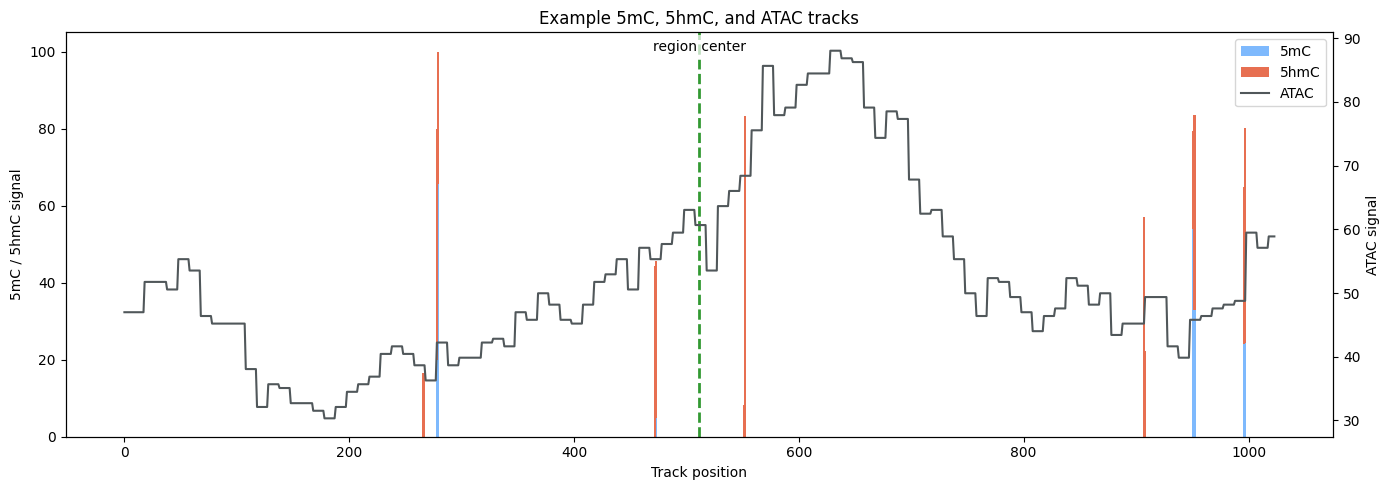

In [46]:
selected_idx = np.random.randint(len(df_dmr))
selected_idx = 666
print(f"Example region: {df_dmr.loc[selected_idx, 'anno']}")

m5c_track = np.asarray(mcg_tracks[selected_idx])
hm5c_track = np.asarray(hmcg_tracks[selected_idx])
atac_track = np.asarray(atac_tracks[selected_idx]) * 1000
positions = np.arange(len(m5c_track))
center_pos = (len(m5c_track) - 1) / 2

fig, ax = plt.subplots(figsize=(14, 5))
ax_atac = ax.twinx()

bars_5mc = ax.bar(positions, m5c_track, color="#7eb9fd", width=2, label="5mC")
bars_5hmc = ax.bar(positions, hm5c_track, bottom=m5c_track, color="#e76f51", width=2, label="5hmC")
line_atac, = ax_atac.plot(positions, atac_track, color="#50575A", linewidth=1.5, label="ATAC")

ax.axvline(center_pos, color="green", linestyle="--", linewidth=2, alpha=0.8)
ax.text(
    center_pos,
    ax.get_ylim()[1] * 0.98,
    "region center",
    ha="center",
    va="top",
    fontsize=10,
    color="black",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
)

ax.set_title("Example 5mC, 5hmC, and ATAC tracks")
ax.set_xlabel("Track position")
ax.set_ylabel("5mC / 5hmC signal")
ax_atac.set_ylabel("ATAC signal")

handles = [bars_5mc, bars_5hmc, line_atac]
labels = ["5mC", "5hmC", "ATAC"]
ax.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()

In [55]:
# Non-Evo2 Cross-Hyena baselines on DMRs: 5mC only vs 5mC+sequence vs 5mC+sequence+ATAC
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_dmrs = min(1000, len(df_dmr), len(seqs), len(mcg_tracks), len(hmcg_tracks), len(atac_tracks))
train_ratio = 0.8
batch_size = 16
hidden_dim = 64
num_epochs = 50
learning_rate = 1e-3

seq_len = min(
    len(mcg_tracks[0]),
    len(hmcg_tracks[0]),
    len(atac_tracks[0]),
    len(seqs[0]),
)

base_to_index = {"A": 0, "C": 1, "G": 2, "T": 3}

def normalize_sequence(sequence):
    if isinstance(sequence, str):
        return sequence.upper()
    if isinstance(sequence, (list, tuple, np.ndarray)):
        return "".join(sequence).upper()
    raise TypeError(f"Unsupported sequence type: {type(sequence)}")

def sequence_to_base_ids(sequence, seq_len: int) -> torch.Tensor:
    sequence_str = normalize_sequence(sequence)
    base_ids = torch.zeros(seq_len, dtype=torch.long)
    for pos, base in enumerate(sequence_str[:seq_len]):
        base_ids[pos] = base_to_index.get(base, 0)
    return base_ids

query_tensor = torch.tensor(np.stack([
    np.asarray(mcg_tracks[idx][:seq_len], dtype=np.float32)
    for idx in range(num_dmrs)
]), dtype=torch.float32).unsqueeze(-1)
hm5c_target = torch.tensor(np.stack([
    np.asarray(hmcg_tracks[idx][:seq_len], dtype=np.float32)
    for idx in range(num_dmrs)
]), dtype=torch.float32).unsqueeze(-1)
atac_tensor = torch.tensor(np.stack([
    np.asarray(atac_tracks[idx][:seq_len], dtype=np.float32)
    for idx in range(num_dmrs)
]), dtype=torch.float32).unsqueeze(-1)
base_ids_tensor = torch.stack([
    sequence_to_base_ids(seqs[idx], seq_len)
    for idx in range(num_dmrs)
])
sequence_onehot = F.one_hot(base_ids_tensor, num_classes=4).float()
loss_mask = find_cpg_candidate_positions(base_ids_tensor).unsqueeze(-1).float()

perm = torch.randperm(num_dmrs)
train_size = int(num_dmrs * train_ratio)
train_idx = perm[:train_size]
val_idx = perm[train_size:]

train_dataset = torch.utils.data.TensorDataset(
    query_tensor[train_idx],
    sequence_onehot[train_idx],
    atac_tensor[train_idx],
    hm5c_target[train_idx],
    loss_mask[train_idx],
)
val_dataset = torch.utils.data.TensorDataset(
    query_tensor[val_idx],
    sequence_onehot[val_idx],
    atac_tensor[val_idx],
    hm5c_target[val_idx],
    loss_mask[val_idx],
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

class MinimalCrossHyenaRegressor(nn.Module):
    def __init__(self, seq_len: int, query_dim: int, context_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.query_proj = nn.Linear(query_dim, hidden_dim)
        self.context_proj = nn.Linear(context_dim, hidden_dim)
        self.cross = CrossHyenaLayer(hidden_dim, seq_len)
        self.norm = nn.LayerNorm(hidden_dim)
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, query_track: torch.Tensor, context_track: torch.Tensor) -> torch.Tensor:
        query = self.query_proj(query_track)
        context = self.context_proj(context_track)
        hidden = self.cross(query, context)
        hidden = self.norm(hidden)
        return self.head(hidden)

def masked_mse_loss(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    squared_error = (pred - target).pow(2)
    return (squared_error * mask).sum() / mask.sum().clamp_min(1.0)

def build_context(query_batch, sequence_batch, atac_batch, mode):
    if mode == "query_only":
        return query_batch
    if mode == "sequence":
        return sequence_batch
    if mode == "sequence_atac":
        return torch.cat([sequence_batch, atac_batch], dim=-1)
    raise ValueError(f"Unknown mode: {mode}")

def evaluate(model, loader, mode):
    model.eval()
    total_loss = 0.0
    total_count = 0
    preds = []
    targets = []
    masks = []
    with torch.no_grad():
        for query_batch, sequence_batch, atac_batch, target_batch, mask_batch in loader:
            query_batch = query_batch.to(device)
            sequence_batch = sequence_batch.to(device)
            atac_batch = atac_batch.to(device)
            target_batch = target_batch.to(device)
            mask_batch = mask_batch.to(device)

            context_batch = build_context(query_batch, sequence_batch, atac_batch, mode)
            pred = model(query_batch, context_batch)
            loss = masked_mse_loss(pred, target_batch, mask_batch)

            batch_count = query_batch.size(0)
            total_loss += loss.item() * batch_count
            total_count += batch_count
            preds.append(pred.detach().cpu())
            targets.append(target_batch.detach().cpu())
            masks.append(mask_batch.detach().cpu())

    preds = torch.cat(preds, dim=0)
    targets = torch.cat(targets, dim=0)
    masks = torch.cat(masks, dim=0)
    ss_res = (((targets - preds) ** 2) * masks).sum()
    masked_targets = targets[masks.bool()]
    target_mean = masked_targets.mean() if masked_targets.numel() > 0 else torch.tensor(0.0)
    ss_tot = (((targets - target_mean) ** 2) * masks).sum().clamp_min(1e-12)
    r2 = 1.0 - (ss_res / ss_tot)
    return total_loss / max(total_count, 1), r2.item()

def train_and_evaluate(model_name, mode):
    context_dim = {"query_only": 1, "sequence": 4, "sequence_atac": 5}[mode]
    model = MinimalCrossHyenaRegressor(
        seq_len=seq_len,
        query_dim=1,
        context_dim=context_dim,
        hidden_dim=hidden_dim,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for query_batch, sequence_batch, atac_batch, target_batch, mask_batch in train_loader:
            query_batch = query_batch.to(device)
            sequence_batch = sequence_batch.to(device)
            atac_batch = atac_batch.to(device)
            target_batch = target_batch.to(device)
            mask_batch = mask_batch.to(device)

            context_batch = build_context(query_batch, sequence_batch, atac_batch, mode)

            optimizer.zero_grad()
            pred = model(query_batch, context_batch)
            loss = masked_mse_loss(pred, target_batch, mask_batch)
            loss.backward()
            optimizer.step()

            batch_count = query_batch.size(0)
            running_loss += loss.item() * batch_count
            seen += batch_count

        train_loss = running_loss / max(seen, 1)
        val_loss, val_r2 = evaluate(model, val_loader, mode)
        history.append({
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_r2": val_r2,
        })
        print(f"[{model_name}] Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_r2={val_r2:.4f}")

    final_val_loss, final_val_r2 = evaluate(model, val_loader, mode)
    print(f"[{model_name}] Final validation R2: {final_val_r2:.4f}")
    return history, {
        "model": model_name,
        "final_val_loss": final_val_loss,
        "final_val_r2": final_val_r2,
    }

baseline_specs = [
    ("5mC-only Cross-Hyena", "query_only"),
    ("5mC+Sequence Cross-Hyena", "sequence"),
    ("5mC+Sequence+ATAC Cross-Hyena", "sequence_atac"),
]

all_history = []
summary_rows = []
for model_name, mode in baseline_specs:
    history, summary = train_and_evaluate(model_name, mode)
    all_history.extend(history)
    summary_rows.append(summary)
    print()

print(f"Using {num_dmrs} DMRs without Evo2")
print("Query track: 5mC")
print("Target track: 5hmC")
print("Context comparison: self 5mC vs one-hot sequence vs one-hot sequence + ATAC")
print("Loss: masked to CG/GC positions only")

history_df = pd.DataFrame(all_history)
summary_df = pd.DataFrame(summary_rows).sort_values("final_val_r2", ascending=False).reset_index(drop=True)
summary_df

C-only Cross-Hyena] Epoch 01 | train_loss=936.3249 | val_loss=881.6835 | val_r2=-0.7120
C-only Cross-Hyena] Epoch 02 | train_loss=772.8313 | val_loss=738.0815 | val_r2=-0.4329
C-only Cross-Hyena] Epoch 03 | train_loss=648.1909 | val_loss=622.0974 | val_r2=-0.2076
C-only Cross-Hyena] Epoch 04 | train_loss=561.9485 | val_loss=553.1554 | val_r2=-0.0738
C-only Cross-Hyena] Epoch 05 | train_loss=520.0058 | val_loss=524.7909 | val_r2=-0.0188
C-only Cross-Hyena] Epoch 06 | train_loss=495.8221 | val_loss=500.7435 | val_r2=0.0281
C-only Cross-Hyena] Epoch 07 | train_loss=484.2800 | val_loss=486.4151 | val_r2=0.0554
C-only Cross-Hyena] Epoch 08 | train_loss=459.9079 | val_loss=460.1463 | val_r2=0.1066
C-only Cross-Hyena] Epoch 09 | train_loss=443.1598 | val_loss=446.4668 | val_r2=0.1344
C-only Cross-Hyena] Epoch 10 | train_loss=434.3614 | val_loss=441.9544 | val_r2=0.1430
C-only Cross-Hyena] Epoch 11 | train_loss=426.9842 | val_loss=437.1693 | val_r2=0.1528
C-only Cross-Hyena] Epoch 12 | train_l

,model,final_val_loss,final_val_r2
0,5mC+Sequence+ATAC Cross-Hyena,399.464290,0.227196
1,5mC-only Cross-Hyena,435.655250,0.155632
2,5mC+Sequence Cross-Hyena,456.109236,0.115319


In [56]:
# Compare Cross-Hyena vs cross-attention vs MLP under the same 5mC+sequence+ATAC setting
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

comparison_mode = "sequence_atac"
comparison_context = build_context(query_tensor, sequence_onehot, atac_tensor, comparison_mode)
comparison_context_dim = comparison_context.shape[-1]
comparison_query_dim = query_tensor.shape[-1]

train_dataset_arch = torch.utils.data.TensorDataset(
    query_tensor[train_idx],
    comparison_context[train_idx],
    hm5c_target[train_idx],
    loss_mask[train_idx],
)
val_dataset_arch = torch.utils.data.TensorDataset(
    query_tensor[val_idx],
    comparison_context[val_idx],
    hm5c_target[val_idx],
    loss_mask[val_idx],
)

train_loader_arch = torch.utils.data.DataLoader(train_dataset_arch, batch_size=batch_size, shuffle=True)
val_loader_arch = torch.utils.data.DataLoader(val_dataset_arch, batch_size=batch_size, shuffle=False)

class CrossAttentionRegressor(nn.Module):
    def __init__(self, query_dim: int, context_dim: int, hidden_dim: int = 64, num_heads: int = 4):
        super().__init__()
        self.query_proj = nn.Linear(query_dim, hidden_dim)
        self.context_proj = nn.Linear(context_dim, hidden_dim)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim)
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, query_track: torch.Tensor, context_track: torch.Tensor) -> torch.Tensor:
        query = self.query_proj(query_track)
        context = self.context_proj(context_track)
        hidden, _ = self.attn(query, context, context, need_weights=False)
        hidden = self.norm(hidden)
        return self.head(hidden)

class PositionwiseMLPRegressor(nn.Module):
    def __init__(self, query_dim: int, context_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(query_dim + context_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, query_track: torch.Tensor, context_track: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([query_track, context_track], dim=-1))

def evaluate_architecture(model, loader):
    model.eval()
    total_loss = 0.0
    total_count = 0
    preds = []
    targets = []
    masks = []
    with torch.no_grad():
        for query_batch, context_batch, target_batch, mask_batch in loader:
            query_batch = query_batch.to(device)
            context_batch = context_batch.to(device)
            target_batch = target_batch.to(device)
            mask_batch = mask_batch.to(device)

            pred = model(query_batch, context_batch)
            loss = masked_mse_loss(pred, target_batch, mask_batch)

            batch_count = query_batch.size(0)
            total_loss += loss.item() * batch_count
            total_count += batch_count
            preds.append(pred.detach().cpu())
            targets.append(target_batch.detach().cpu())
            masks.append(mask_batch.detach().cpu())

    preds = torch.cat(preds, dim=0)
    targets = torch.cat(targets, dim=0)
    masks = torch.cat(masks, dim=0)
    ss_res = (((targets - preds) ** 2) * masks).sum()
    masked_targets = targets[masks.bool()]
    target_mean = masked_targets.mean() if masked_targets.numel() > 0 else torch.tensor(0.0)
    ss_tot = (((targets - target_mean) ** 2) * masks).sum().clamp_min(1e-12)
    r2 = 1.0 - (ss_res / ss_tot)
    return total_loss / max(total_count, 1), r2.item()

def train_architecture(model_name, model_factory):
    model = model_factory().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for query_batch, context_batch, target_batch, mask_batch in train_loader_arch:
            query_batch = query_batch.to(device)
            context_batch = context_batch.to(device)
            target_batch = target_batch.to(device)
            mask_batch = mask_batch.to(device)

            optimizer.zero_grad()
            pred = model(query_batch, context_batch)
            loss = masked_mse_loss(pred, target_batch, mask_batch)
            loss.backward()
            optimizer.step()

            batch_count = query_batch.size(0)
            running_loss += loss.item() * batch_count
            seen += batch_count

        train_loss = running_loss / max(seen, 1)
        val_loss, val_r2 = evaluate_architecture(model, val_loader_arch)
        history.append({
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_r2": val_r2,
        })
        print(f"[{model_name}] Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_r2={val_r2:.4f}")

    final_val_loss, final_val_r2 = evaluate_architecture(model, val_loader_arch)
    print(f"[{model_name}] Final validation R2: {final_val_r2:.4f}")
    return history, {
        "model": model_name,
        "final_val_loss": final_val_loss,
        "final_val_r2": final_val_r2,
    }

architecture_specs = [
    (
        "Cross-Hyena",
        lambda: MinimalCrossHyenaRegressor(
            seq_len=seq_len,
            query_dim=comparison_query_dim,
            context_dim=comparison_context_dim,
            hidden_dim=hidden_dim,
        ),
    ),
    (
        "Cross-Attention",
        lambda: CrossAttentionRegressor(
            query_dim=comparison_query_dim,
            context_dim=comparison_context_dim,
            hidden_dim=hidden_dim,
            num_heads=4,
        ),
    ),
    (
        "MLP",
        lambda: PositionwiseMLPRegressor(
            query_dim=comparison_query_dim,
            context_dim=comparison_context_dim,
            hidden_dim=hidden_dim,
        ),
    ),
]

arch_history = []
arch_summary_rows = []
for model_name, model_factory in architecture_specs:
    history, summary = train_architecture(model_name, model_factory)
    arch_history.extend(history)
    arch_summary_rows.append(summary)
    print()

print(f"Using {num_dmrs} DMRs without Evo2")
print("Query track: 5mC")
print("Target track: 5hmC")
print("Shared context: one-hot sequence + ATAC")
print("Architecture comparison: Cross-Hyena vs cross-attention vs MLP")
print("Loss: masked to CG/GC positions only")

arch_history_df = pd.DataFrame(arch_history)
arch_summary_df = pd.DataFrame(arch_summary_rows).sort_values("final_val_r2", ascending=False).reset_index(drop=True)
arch_summary_df

[Cross-Hyena] Epoch 01 | train_loss=905.5374 | val_loss=853.0142 | val_r2=-0.6563
[Cross-Hyena] Epoch 02 | train_loss=748.5805 | val_loss=715.7702 | val_r2=-0.3896
[Cross-Hyena] Epoch 03 | train_loss=630.5807 | val_loss=609.4380 | val_r2=-0.1830
[Cross-Hyena] Epoch 04 | train_loss=553.8070 | val_loss=548.4301 | val_r2=-0.0647
[Cross-Hyena] Epoch 05 | train_loss=517.0712 | val_loss=524.3045 | val_r2=-0.0180
[Cross-Hyena] Epoch 06 | train_loss=505.2515 | val_loss=517.1291 | val_r2=-0.0042
[Cross-Hyena] Epoch 07 | train_loss=503.3996 | val_loss=512.9623 | val_r2=0.0040
[Cross-Hyena] Epoch 08 | train_loss=486.8389 | val_loss=478.9967 | val_r2=0.0703
[Cross-Hyena] Epoch 09 | train_loss=475.6371 | val_loss=467.7664 | val_r2=0.0923
[Cross-Hyena] Epoch 10 | train_loss=491.0018 | val_loss=505.4480 | val_r2=0.0182
[Cross-Hyena] Epoch 11 | train_loss=471.4464 | val_loss=451.3997 | val_r2=0.1243
[Cross-Hyena] Epoch 12 | train_loss=449.8084 | val_loss=449.9080 | val_r2=0.1273
[Cross-Hyena] Epoch 13

,model,final_val_loss,final_val_r2
0,Cross-Hyena,388.475476,0.248286
1,Cross-Attention,435.081968,0.156749
2,MLP,440.583049,0.146351


In [ ]:
# Check whether non-zero 5mC / 5hmC positions fall on C/G bases in the first 100 DMRs
num_regions_to_check = min(100, len(seqs), len(mcg_tracks), len(hmcg_tracks))
print(f"Checking first {num_regions_to_check} DMRs")

def summarize_track_base_consistency(seqs, tracks, track_name, num_regions, max_examples=10):
    total_nonzero = 0
    total_cg = 0
    total_non_cg = 0
    bad_examples = []

    for region_idx in range(num_regions):
        sequence = np.frombuffer(seqs[region_idx][: len(tracks[region_idx])].upper().encode("ascii"), dtype=np.uint8)
        track = np.asarray(tracks[region_idx], dtype=np.float32)[: len(sequence)]

        nonzero_mask = np.isfinite(track) & (~np.isclose(track, 0.0))
        if not np.any(nonzero_mask):
            continue

        cg_base_mask = (sequence == ord("C")) | (sequence == ord("G"))
        bad_mask = nonzero_mask & (~cg_base_mask)

        total_nonzero += int(nonzero_mask.sum())
        total_cg += int((nonzero_mask & cg_base_mask).sum())
        total_non_cg += int(bad_mask.sum())

        if bad_mask.any() and len(bad_examples) < max_examples:
            bad_positions = np.flatnonzero(bad_mask)
            for pos in bad_positions[: max_examples - len(bad_examples)]:
                bad_examples.append({
                    "region_idx": int(region_idx),
                    "position": int(pos),
                    "base": chr(sequence[pos]),
                    "value": float(track[pos]),
                })

    fraction_non_cg = total_non_cg / total_nonzero if total_nonzero > 0 else 0.0
    return {
        "track": track_name,
        "regions_checked": num_regions,
        "total_nonzero_positions": total_nonzero,
        "cg_positions": total_cg,
        "non_cg_positions": total_non_cg,
        "fraction_non_cg": fraction_non_cg,
        "bad_examples": bad_examples,
    }

m5c_consistency = summarize_track_base_consistency(
    seqs, mcg_tracks, "5mC", num_regions=num_regions_to_check
    )
hm5c_consistency = summarize_track_base_consistency(
    seqs, hmcg_tracks, "5hmC", num_regions=num_regions_to_check
    )

for summary in [m5c_consistency, hm5c_consistency]:
    print(f"Track: {summary['track']}")
    print(f"  Regions checked: {summary['regions_checked']}")
    print(f"  Non-zero positions: {summary['total_nonzero_positions']}")
    print(f"  On C/G: {summary['cg_positions']}")
    print(f"  Not on C/G: {summary['non_cg_positions']}")
    print(f"  Fraction not on C/G: {summary['fraction_non_cg']:.6f}")
    if summary['bad_examples']:
        print("  Example mismatches:")
        for example in summary['bad_examples']:
            print(
                f"    region={example['region_idx']}, pos={example['position']}, "
                f"base={example['base']}, value={example['value']:.4f}"
            )
    else:
        print("  No mismatches found in sampled examples.")
    print()

consistency_df = pd.DataFrame([
    {k: v for k, v in m5c_consistency.items() if k != "bad_examples"},
    {k: v for k, v in hm5c_consistency.items() if k != "bad_examples"},
])
consistency_df

In [ ]:
# Inspect whether mismatches come from coordinate off-by-one or interval expansion
region_idx = 1
positions_to_check = [709, 855, 880]
row = df_dmr.iloc[region_idx]
chrom = "chr" + str(row["chr"])
region_start = int(row["start_expanded"])
region_end = int(row["end_expanded"])
sequence = seqs[region_idx].upper()

print(f"Region {region_idx}: {chrom}:{region_start}-{region_end}")

def inspect_position(track_name, tbx, positions):
    print(f"\n{track_name}")
    raw_records = [line.split("\t") for line in tbx.fetch(chrom.replace("chr", ""), region_start, region_end + 1)]
    for pos in positions:
        genomic_pos_1based = region_start + pos
        genomic_pos_0based = genomic_pos_1based - 1
        local_base = sequence[pos] if pos < len(sequence) else None
        left_base = sequence[pos - 1] if pos - 1 >= 0 else None
        right_base = sequence[pos + 1] if pos + 1 < len(sequence) else None
        overlapping = [
            rec for rec in raw_records
            if int(rec[1]) <= genomic_pos_0based < int(rec[2])
        ]
        print(
            f"pos={pos}, genomic_1based={genomic_pos_1based}, genomic_0based={genomic_pos_0based}, "
            f"bases={left_base}{local_base}{right_base}, overlapping_records={len(overlapping)}"
        )
        for rec in overlapping[:5]:
            print(
                f"  raw interval: start0={rec[1]}, end0={rec[2]}, value={rec[3]} "
                f"(length={int(rec[2]) - int(rec[1])})"
            )
        if not overlapping:
            print("  no overlapping raw interval found")

inspect_position("5hmC", tbx_5hmc, positions_to_check)
inspect_position("5mC", tbx_5mc, positions_to_check)

In [ ]:
# Check local coordinate windows around mismatch positions
region_idx = 1
positions_to_check = [709, 855, 880]
row = df_dmr.iloc[region_idx]
chrom = str(row["chr"])
region_start = int(row["start_expanded"])
region_end = int(row["end_expanded"])
track_5hmc = np.asarray(hmcg_tracks[region_idx])
track_5mc = np.asarray(mcg_tracks[region_idx])

for pos in positions_to_check:
    genomic_pos_1based = region_start + pos
    print(f"\nLocal check for pos={pos}, genomic_1based={genomic_pos_1based}")
    print(f"  track 5hmC value={track_5hmc[pos]:.4f}, track 5mC value={track_5mc[pos]:.4f}")
    for delta in [-2, -1, 0, 1, 2]:
        qstart = genomic_pos_1based + delta - 1
        qend = genomic_pos_1based + delta
        hm_records = list(tbx_5hmc.fetch(chrom, qstart, qend))
        mc_records = list(tbx_5mc.fetch(chrom, qstart, qend))
        print(f"  delta={delta:+d} query0=[{qstart}, {qend})")
        print(f"    5hmC raw: {hm_records[:3]}")
        print(f"    5mC raw: {mc_records[:3]}")